# Memory & State 관리

Agent가 대화를 이어가려면 **State를 저장하고 복원**하는 기능이 필요하다. LangGraph는 이를 위해 Checkpointer(Short-term Memory)와 Store(Long-term Memory)를 제공한다.

In [ ]:
from dotenv import load_dotenv

load_dotenv()

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 기본 챗봇 그래프

Memory 기능을 실습하기 위한 간단한 챗봇 그래프를 먼저 구성한다.

In [ ]:
def simple_chatbot(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}


simple_builder = StateGraph(MessagesState)
simple_builder.add_node("chatbot", simple_chatbot)

simple_builder.add_edge(START, "chatbot")
simple_builder.add_edge("chatbot", END)

print("기본 챗봇 그래프 구성 완료")

## Checkpointer

Checkpointer는 **그래프의 State 스냅샷을 저장하고 복원**하는 기능이다. 그래프 실행 시작 시와 각 노드 실행 후에 자동으로 State 스냅샷을 저장하며, 같은 `thread_id`로 다시 호출하면 마지막 스냅샷부터 이어서 실행한다.

- `MemorySaver`: 메모리에 저장 (개발/테스트용, 프로세스 종료 시 사라짐)
- `PostgresSaver`: PostgreSQL에 저장 (프로덕션용, 서버 재시작 후에도 유지)
- `thread_id`: 대화 세션을 구분하는 ID

In [ ]:
memory = MemorySaver()

# checkpointer와 함께 컴파일
graph_with_memory = simple_builder.compile(checkpointer=memory)

print("Checkpointer 연결 완료")

In [ ]:
# thread_id로 대화 세션을 구분한다
config = {"configurable": {"thread_id": "session-1"}}

# 첫 번째 대화
result = graph_with_memory.invoke(
    {"messages": [("user", "내 이름은 Alice야. 반가워!")]},
    config=config,
)
print(result["messages"][-1].content)
print()

In [ ]:
# 두 번째 대화 - 같은 thread_id이므로 이전 대화를 기억한다
result = graph_with_memory.invoke(
    {"messages": [("user", "내 이름이 뭐라고 했지?")]},
    config=config,
)
print(result["messages"][-1].content)
print()

In [ ]:
# 다른 thread_id는 별도의 세션이다
config2 = {"configurable": {"thread_id": "session-2"}}

result = graph_with_memory.invoke(
    {"messages": [("user", "내 이름이 뭐야?")]},
    config=config2,
)
print(result["messages"][-1].content)
print("-> 다른 세션이므로 이름을 모른다")

### 저장된 State 확인

`get_state(config)`로 현재 저장된 State를 확인할 수 있다. 반환되는 `StateSnapshot` 객체의 `values`에 실제 State 데이터가 들어있다.

```python
state = graph.get_state(config)
state.values    # {"messages": [...]} — 현재 State 데이터
state.next      # 다음에 실행될 노드 (완료 시 빈 튜플)
state.config    # checkpoint_id가 포함된 config
```

In [ ]:
state = graph_with_memory.get_state(config)
print(f"저장된 메시지 수: {len(state.values['messages'])}")
for msg in state.values["messages"]:
    print(f"  [{msg.type}] {msg.content[:100]}")

## PostgreSQL Checkpointer

`MemorySaver`는 메모리에만 저장하므로 서버가 재시작되면 상태가 사라진다. 프로덕션에서는 `PostgresSaver`로 영속화한다. 사용법은 `MemorySaver`와 동일하고, 연결 대상만 다르다.

```bash
uv add langgraph-checkpoint-postgres "psycopg[binary]"
```

In [ ]:
import os
from langgraph.checkpoint.postgres import PostgresSaver

DATABASE_URL = os.environ["DATABASE_URL"]

# from_conn_string은 내부적으로 커넥션 풀을 생성하고 with 블록 종료 시 정리한다.
with PostgresSaver.from_conn_string(DATABASE_URL) as pg_saver:
    pg_saver.setup()

    pg_graph = simple_builder.compile(checkpointer=pg_saver)
    print("PostgresSaver 연결 완료")

    config_pg = {"configurable": {"thread_id": "pg-1"}}

    result = pg_graph.invoke(
        {"messages": [("user", "내 이름은 김철수야. 기억해줘.")]},
        config_pg,
    )
    print(result["messages"][-1].content)

    # 이어서 대화 - 같은 thread_id이므로 이전 대화가 유지된다
    result = pg_graph.invoke(
        {"messages": [("user", "내 이름이 뭐였지?")]},
        config_pg,
    )
    print(result["messages"][-1].content)

## 대화 요약 관리

대화가 길어지면 메시지가 계속 누적되어 토큰 비용이 증가한다. 전체 토큰 수가 임계값을 넘으면 **요약 노드**가 실행되어, `trim_messages`로 최근 메시지만 남기고 나머지를 요약으로 대체하는 패턴을 구현한다.

```
START → chatbot → 토큰 초과 → summarize → END
                → 토큰 이내 →             END
```

핵심 도구:
- `trim_messages`: 토큰 기준으로 최근 메시지만 유지한다
- `RemoveMessage`: State에서 특정 메시지를 **ID 기반으로 삭제**한다. `add_messages` reducer가 `RemoveMessage`를 만나면 해당 ID의 메시지를 제거한다

요약 후 State 구조:
```
messages: [최근 user 메시지, 최근 ai 응답]   ← trim 후 남은 것만
summary: "이전 대화 요약 텍스트"              ← 삭제된 메시지의 요약
```

`RemoveMessage`로 삭제된 메시지는 현재 State에서 완전히 사라진다. Checkpointer 히스토리에는 과거 스냅샷이 남아있지만, 그래프가 사용하는 현재 State에는 없다. 따라서 요약의 품질이 중요하다.
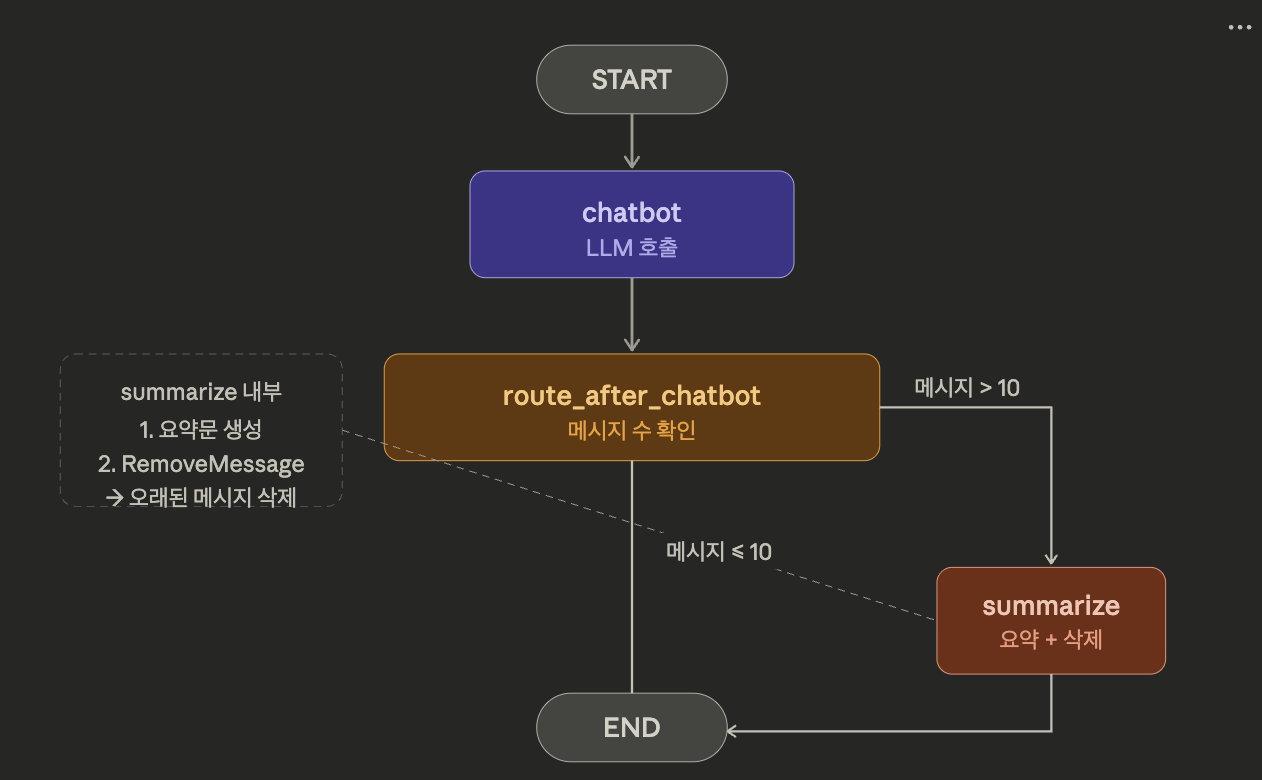

In [ ]:
from langchain_core.messages import RemoveMessage, SystemMessage, trim_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

MAX_TOKENS = 300  # 이 토큰 수를 초과하면 요약 트리거 (실습용으로 낮게 설정)


class SummaryState(MessagesState):
    """대화 메시지와 요약을 함께 관리하는 State."""
    summary: str


def chatbot_with_summary(state: SummaryState):
    """요약이 있으면 시스템 메시지로 추가하여 LLM에 전달한다."""
    messages = state["messages"]
    summary = state.get("summary", "")

    system_content = "모든 답변을 2문장 이내로 짧게 해줘."
    if summary:
        system_content += f"\n\n이전 대화 요약: {summary}"

    messages = [SystemMessage(content=system_content)] + messages

    response = llm.invoke(messages)
    return {"messages": [response]}


def route_after_chatbot(state: SummaryState):
    """전체 메시지의 토큰 수가 MAX_TOKENS 초과 → summarize, 그 외 → END"""
    token_count = llm.get_num_tokens_from_messages(state["messages"])
    if token_count > MAX_TOKENS:
        return "summarize"
    return END


def summarize_conversation(state: SummaryState):
    """이전 메시지를 요약하고, 오래된 메시지를 삭제한다."""
    messages = state["messages"]
    existing_summary = state.get("summary", "")

    if existing_summary:
        prompt = (
            f"기존 요약:\n{existing_summary}\n\n"
            f"위 요약에 다음 새 메시지 내용을 반영하여 요약을 업데이트해줘:\n\n"
        )
    else:
        prompt = "다음 대화를 간결하게 요약해줘:\n\n"

    # 최근 메시지를 토큰 기준으로 유지하고 나머지를 요약 대상으로 분리
    kept = trim_messages(
        messages,
        max_tokens=100,
        strategy="last",
        token_counter=llm,
        start_on="human",
    )
    kept_ids = {msg.id for msg in kept}
    old_messages = [msg for msg in messages if msg.id not in kept_ids]

    for msg in old_messages:
        if msg.type in ("human", "ai") and msg.content:
            prompt += f"{msg.type}: {msg.content}\n"

    summary_response = llm.invoke(prompt)

    delete_messages = [RemoveMessage(id=msg.id) for msg in old_messages]

    return {
        "summary": summary_response.content,
        "messages": delete_messages,
    }

In [ ]:
from IPython.display import Image, display

summary_builder = StateGraph(SummaryState)

# 노드 등록
summary_builder.add_node("chatbot", chatbot_with_summary)
summary_builder.add_node("summarize", summarize_conversation)

# 엣지 연결
summary_builder.add_edge(START, "chatbot")
summary_builder.add_conditional_edges("chatbot", route_after_chatbot, {
    "summarize": "summarize",
    END: END,
})
summary_builder.add_edge("summarize", END)

summary_memory = MemorySaver()
summary_graph = summary_builder.compile(checkpointer=summary_memory)

display(Image(summary_graph.get_graph().draw_mermaid_png()))

In [ ]:
# 대화를 여러 번 반복하여 요약이 동작하는지 확인
config = {"configurable": {"thread_id": "summary-test00"}}

questions = [
    "파이썬이 뭐야?",
    "자바스크립트와 비교하면?",
    "웹 개발에는 어떤 게 좋아?",
    "데이터 분석에는?",
    "머신러닝 프레임워크 추천해줘",
    "딥러닝도 파이썬이 좋아?",
]

for q in questions:
    result = summary_graph.invoke(
        {"messages": [("user", q)]},
        config=config,
    )
    token_count = llm.get_num_tokens_from_messages(result["messages"])
    print(f"Q: {q}")
    print(f"A: {result['messages'][-1].content[:100] if result['messages'] else '(빈 메시지)'}...")
    print(f"  메시지 수: {len(result['messages'])}, 토큰 수: {token_count}")
    if result.get("summary"):
        print(f"  요약: {result['summary'][:100]}...")
    print()

## Long-term Memory

Checkpointer는 **Short-term Memory**다. thread_id 단위로 대화 기록을 저장하지만, 다른 스레드에서는 접근할 수 없다.

**Long-term Memory**는 스레드를 넘어서 유저별 선호도, 학습 내용 등을 기억한다.

| 구분 | Short-term (Checkpointer) | Long-term (Store) |
|------|---------------------------|-------------------|
| 범위 | thread_id 단위 | 유저/네임스페이스 단위 |
| 수명 | thread_id 범위 내 | 명시적 삭제까지 |
| 용도 | 대화 기록, 중단/재개 | 유저 선호도, 학습 내용 |

### Store의 데이터 구조: namespace, key, value

- **namespace**: 데이터를 분류하는 계층 구조. `("users", "alice", "preferences")`처럼 튜플로 표현한다. 구조는 자유롭게 설계할 수 있다.
- **key**: namespace 안에서 개별 항목을 식별하는 이름.
- **value**: 실제 저장되는 데이터 (dict).

### `search`는 prefix 매칭이다

`store.search(namespace)`는 해당 namespace의 **하위 namespace까지 포함**하여 검색한다.

```python
# ("users", "alice") 하위의 모든 항목을 가져온다
# → preferences, facts, instructions 등 전부 포함
store.search(("users", "alice"))

# ("users", "alice", "preferences") 하위만 가져온다
store.search(("users", "alice", "preferences"))
```

따라서 namespace를 세분화해두면 **좁게 검색할 수도, 넓게 검색할 수도** 있다. 아래 그래프 예시에서 `store.search(("users", user_id))`로 유저의 모든 정보를 한 번에 조회하는 것이 이 원리다.

### 어떤 데이터를 저장할 수 있는가?

| namespace 예시 | 용도 | value 예시 |
|---|---|---|
| `("users", "alice", "preferences")` | 응답 스타일 선호 | `{"tone": "반말", "language": "한국어"}` |
| `("users", "alice", "facts")` | 대화에서 파악한 사실 | `{"fact": "백엔드 개발자, Python 주력"}` |
| `("users", "alice", "instructions")` | 유저가 직접 지시한 규칙 | `{"rule": "코드 예시는 항상 타입 힌트 포함"}` |
| `("users", "alice", "history")` | 과거 대화 요약 | `{"summary": "RAG 파이프라인 구축 논의"}` |

preference는 가장 기본적인 예시일 뿐이고, 실제로는 **유저에 대해 기억할 가치가 있는 모든 것**을 저장한다.

### 그래프에서 Store 사용하기

그래프 노드에서 Store에 접근하려면 함수 시그니처에 `*, store: BaseStore`를 추가한다. LangGraph가 컴파일 시 연결된 Store를 자동으로 주입해준다.

```python
def my_node(state: MessagesState, config, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    memories = store.search(("users", user_id))
```

In [ ]:
import os

from langgraph.store.postgres import PostgresStore

DATABASE_URL = os.environ["DATABASE_URL"]

with PostgresStore.from_conn_string(DATABASE_URL) as store:
    store.setup()

    # put(namespace, key, value)
    store.put(
        namespace=("users", "alice", "preferences"),
        key="style",
        value={"tone": "친근한 반말", "language": "한국어"},
    )

    store.put(
        namespace=("users", "alice", "facts"),
        key="job",
        value={"fact": "백엔드 개발자, Python 주력"},
    )

    # search(namespace): 네임스페이스 내 모든 항목 검색
    results = store.search(("users", "alice", "preferences"))
    for item in results:
        print(f"key={item.key}, value={item.value}")

In [ ]:
# 그래프에서 Store 활용
from uuid import uuid4

from langchain_core.messages import SystemMessage
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.store.base import BaseStore
from langgraph.store.postgres import PostgresStore

llm_for_memory = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def memory_chatbot(state: MessagesState, config, *, store: BaseStore):
    user_id = config["configurable"].get("user_id", "default")

    # 유저의 모든 Long-term Memory를 한 번에 조회
    memories = store.search(("users", user_id))
    memory_text = "\n".join(f"- [{'/'.join(m.namespace)}] {m.key}: {m.value}" for m in memories)

    system = f"유저에 대해 알고 있는 정보:\n{memory_text}" if memory_text else "유저 정보 없음"
    messages = [SystemMessage(content=system)] + state["messages"]

    response = llm_for_memory.invoke(messages)

    # 대화에서 새로운 사실을 감지하면 저장
    # 실무에서는 LLM으로 "저장할 만한 사실이 있는가?"를 판단하는 것이 적절하다.
    # 여기서는 간단한 키워드 매칭으로 대체한다.
    # key에 UUID를 사용하여 여러 번 감지해도 덮어쓰지 않고 각각 저장한다.
    user_msg = state["messages"][-1].content if state["messages"] else ""
    if "좋아" in user_msg or "선호" in user_msg:
        store.put(("users", user_id, "preferences"), uuid4().hex[:8], {"note": user_msg})
    if "기억해" in user_msg:
        store.put(("users", user_id, "instructions"), uuid4().hex[:8], {"rule": user_msg})

    return {"messages": [response]}


memory_builder = StateGraph(MessagesState)
memory_builder.add_node("chatbot", memory_chatbot)
memory_builder.add_edge(START, "chatbot")
memory_builder.add_edge("chatbot", END)

with PostgresSaver.from_conn_string(DATABASE_URL) as checkpointer, PostgresStore.from_conn_string(DATABASE_URL) as store:
    checkpointer.setup()
    store.setup()

    memory_graph = memory_builder.compile(
        checkpointer=checkpointer,
        store=store,
    )

    # alice의 대화 — 위에서 저장한 facts, preferences를 참조한다
    config_alice = {"configurable": {"thread_id": "alice-1", "user_id": "alice"}}
    result = memory_graph.invoke(
        {"messages": [("user", "안녕! 오늘 뭐 배울까?")]},
        config_alice,
    )
    print("[alice]")
    print(result["messages"][-1].content[:300])

## 유저 격리 확인

`thread_id`와 `user_id`를 유저별로 다르게 설정하면 Short-term Memory(대화 기록)와 Long-term Memory(유저 정보) 모두 완전히 분리된다.

In [ ]:
with PostgresSaver.from_conn_string(DATABASE_URL) as checkpointer, PostgresStore.from_conn_string(DATABASE_URL) as store:
    checkpointer.setup()
    store.setup()

    multi_graph = memory_builder.compile(checkpointer=checkpointer, store=store)

    # 유저별 Long-term Memory 저장
    store.put(("users", "alice", "facts"), "job", {"fact": "백엔드 개발자"})
    store.put(("users", "bob", "facts"), "job", {"fact": "데이터 분석가"})

    # Alice의 대화
    config_a = {"configurable": {"thread_id": "alice-thread", "user_id": "alice"}}
    multi_graph.invoke({"messages": [("user", "요즘 FastAPI 공부하고 있어")]}, config_a)

    # Bob의 대화
    config_b = {"configurable": {"thread_id": "bob-thread", "user_id": "bob"}}
    multi_graph.invoke({"messages": [("user", "요즘 판다스 성능 최적화를 공부하고 있어")]}, config_b)

    result_a = multi_graph.invoke({"messages": [("user", "내 직업이랑 요즘 관심사가 뭐였지?")]}, config_a)
    result_b = multi_graph.invoke({"messages": [("user", "내 직업이랑 요즘 관심사가 뭐였지?")]}, config_b)
    print(f"[alice] {result_a['messages'][-1].content}")
    print(f"[bob] {result_b['messages'][-1].content}")

    # 같은 유저, 다른 thread_id → Short-term은 접근 불가, Long-term은 유지된다
    config_a2 = {"configurable": {"thread_id": "alice-thread-2", "user_id": "alice"}}
    result_a2 = multi_graph.invoke({"messages": [("user", "내 직업이랑 요즘 관심사가 뭐였지?")]}, config_a2)
    print(f"\n[alice, 새 thread] {result_a2['messages'][-1].content}")